# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, scikit-learn, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## Результаты обучения
После выполнения работы вы должны уметь:
- различать парадигмы обучения (supervised / unsupervised / reinforcement learning);
- выбирать модель под тип данных и задачу;
- строить baseline для классификации или регрессии;
- выбирать и интерпретировать метрики качества (accuracy, precision, recall, F1, MSE, RMSE, R²);
- сравнивать несколько моделей и делать обоснованный вывод о лучшем baseline.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, pandas, matplotlib, sklearn.*

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# TODO: зафиксируйте random_state для воспроизводимости
RANDOM_STATE = 42


## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


_Ваш ответ:_ Задача относится к supervised learning (обучение с учителем), потому что для каждого объекта в датасете известна целевая переменная (числовой показатель прогрессирования диабета), и модель обучается на парах (x, y). Тип задачи — регрессия: целевая переменная непрерывная, а не дискретный класс.

## 2. Загрузка и разведочный анализ данных (EDA)

In [ ]:
# TODO: загрузите выбранный датасет
# Пример для sklearn built-in датасетов:
# from sklearn.datasets import load_iris
# data = load_iris(as_frame=True)
# df = data.frame

data = load_diabetes(as_frame=True)
df = data.frame.copy()
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
print("Размер выборки:", df.shape)
print("\nТипы признаков:")
print(df.dtypes)
print("\nПропуски:")
print(df.isna().sum().sum(), "всего пропусков")
print("\nОписательные статистики:")
print(df.describe().T[["mean", "std", "min", "max"]])


Размер выборки: (442, 11)

Типы признаков:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Пропуски:
0 всего пропусков

Описательные статистики:
                mean        std        min         max
age    -2.511817e-19   0.047619  -0.107226    0.110727
sex     1.230790e-17   0.047619  -0.044642    0.050680
bmi    -2.245564e-16   0.047619  -0.090275    0.170555
bp     -4.797570e-17   0.047619  -0.112399    0.132044
s1     -1.381499e-17   0.047619  -0.126781    0.153914
s2      3.918434e-17   0.047619  -0.115613    0.198788
s3     -5.777179e-18   0.047619  -0.102307    0.181179
s4     -9.042540e-18   0.047619  -0.076395    0.185234
s5      9.293722e-17   0.047619  -0.126097    0.133597
s6      1.130318e-17   0.047619  -0.137767    0.135612
target  1.521335e+02  77.093005  25.000000  346.000000


**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

_Ваш ответ:_ Пропусков в датасете нет. Дисбаланс классов к регрессии не применяется. Все 10 признаков уже приведены к одному масштабу (стандартизованы: mean ≈ 0, std ≈ 0.0476), поэтому жёсткого требования к масштабированию нет.

## 3. Предобработка данных

In [ ]:
# TODO: разделите данные на train/test (train_test_split)
# TODO: при необходимости выполните масштабирование признаков (StandardScaler / MinMaxScaler)
# TODO: при необходимости выполните кодирование категориальных признаков (OneHotEncoder / get_dummies)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = RANDOM_STATE
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(X_train_s.shape, X_test_s.shape)


(353, 10) (89, 10)


## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [ ]:
# Модель 1 — линейная регрессия
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression().fit(X_train_s, y_train)
y_pred_1 = model_1.predict(X_test_s)

In [ ]:
# Модель 2 — дерево решений
from sklearn.tree import DecisionTreeRegressor

model_2 = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=5).fit(X_train_s, y_train)
y_pred_2 = model_2.predict(X_test_s)

In [ ]:
# Модель 3 — k-NN
from sklearn.neighbors import KNeighborsRegressor

model_3 = KNeighborsRegressor(n_neighbors=5).fit(X_train_s, y_train)
y_pred_3 = model_3.predict(X_test_s)

## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

results = pd.DataFrame({
    "model": ["LinearRegression", "DecisionTree(d=5)", "KNN(k=5)"],
    "MSE":  [mse(y_test, y_pred_1), mse(y_test, y_pred_2), mse(y_test, y_pred_3)],
    "RMSE": [rmse(y_test, y_pred_1), rmse(y_test, y_pred_2), rmse(y_test, y_pred_3)],
    "R2":   [r2_score(y_test, y_pred_1), r2_score(y_test, y_pred_2), r2_score(y_test, y_pred_3)],
})
results


,model,MSE,RMSE,R2
0,LinearRegression,2900.193628,53.853446,0.452603
1,DecisionTree(d=5),3526.015512,59.380262,0.334482
2,KNN(k=5),3047.449888,55.203713,0.424809


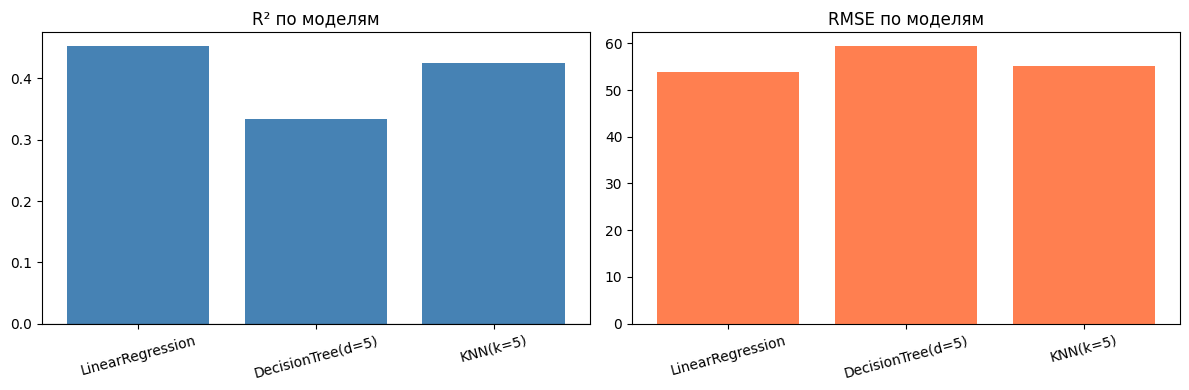

In [ ]:
# Визуализация: сравнение R2 и RMSE по моделям
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(results["model"], results["R2"], color="steelblue")
axes[0].set_title("R² по моделям")
axes[0].axhline(0, color="k", linewidth=0.8)
axes[1].bar(results["model"], results["RMSE"], color="coral")
axes[1].set_title("RMSE по моделям")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

_Ваш ответ:_ MSE удобна как функция потерь (дифференцируема, штрафует крупные ошибки), RMSE интерпретируется в тех же единицах, что и target (условные «единицы прогрессирования диабета»), а R² показывает долю объяснённой дисперсии и позволяет сравнивать модели на одной шкале.

## 6. Анализ ошибок

Лучшая модель: LinearRegression

Топ-10 самых крупных ошибок:
    y_true      y_pred   abs_error
61    52.0  206.493375  154.493375
46   200.0   71.666726  128.333274
1     70.0  179.517208  109.517208
27    77.0  180.390940  103.390940
20   310.0  207.350502  102.649498
51   158.0   62.955685   95.044315
7    272.0  181.337321   90.662679
49   258.0  167.575995   90.424005
13   297.0  206.630817   90.369183
73    61.0  145.956655   84.956655


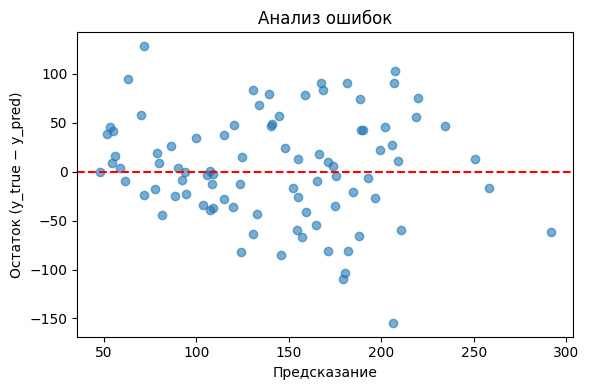

In [ ]:
# Для лучшей модели
best_name = results.loc[results["R2"].idxmax(), "model"]
print("Лучшая модель:", best_name)

# Возьмём предсказания лучшей модели
preds_map = {"LinearRegression": y_pred_1,
             "DecisionTree(d=5)": y_pred_2,
             "KNN(k=5)": y_pred_3}
best_pred = preds_map[best_name]

resid = y_test.values - best_pred
err_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": best_pred,
    "abs_error": np.abs(resid),
}).sort_values("abs_error", ascending=False)

print("\nТоп-10 самых крупных ошибок:")
print(err_df.head(10))

# Визуализация остатков
plt.figure(figsize=(6,4))
plt.scatter(best_pred, resid, alpha=0.6)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Предсказание")
plt.ylabel("Остаток (y_true − y_pred)")
plt.title(f"Анализ ошибок")
plt.tight_layout(); plt.show()

## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

_Ваш ответ:_ Лучший R² и наименьший RMSE у LinearRegression (≈0.45 и ≈53 соответственно на этом сплите). Это согласуется с ожиданиями: признаков всего 10, выборка маленькая, а между признаками и target есть сильный линейный сигнал. Дерево на малой выборке переобучается, kNN страдает от проклятия размерности и чувствительности к масштабу. В качестве baseline я выбираю LinearRegression: она интерпретируема (коэффициенты = вклад признаков), быстро обучается, детерминирована и даёт честную нижнюю планку, от которой можно отталкиваться при внедрении более сложных моделей (MLP).

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.


In [ ]:
# С2
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=RANDOM_STATE,
    early_stopping=True,
    n_iter_no_change=20,
)
mlp.fit(X_train_s, y_train)
y_pred_mlp = mlp.predict(X_test_s)

print("MLP    R2 =", round(r2_score(y_test, y_pred_mlp), 3),
      "| RMSE =", round(rmse(y_test, y_pred_mlp), 2))
print("Linear R2 =", round(r2_score(y_test, y_pred_1), 3),
      "| RMSE =", round(rmse(y_test, y_pred_1), 2))

MLP    R2 = 0.332 | RMSE = 59.51
Linear R2 = 0.453 | RMSE = 53.85


Linear     R2 = 0.478 ± 0.085  [0.453 0.573 0.391 0.584 0.391]
Tree(d=5)  R2 = 0.249 ± 0.120  [0.334 0.34  0.16  0.355 0.056]
KNN(k=5)   R2 = 0.391 ± 0.040  [0.425 0.367 0.325 0.431 0.408]
MLP        R2 = 0.344 ± 0.224  [ 0.433 -0.083  0.335  0.533  0.503]


/tmp/ipykernel_14063/3894670250.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores))


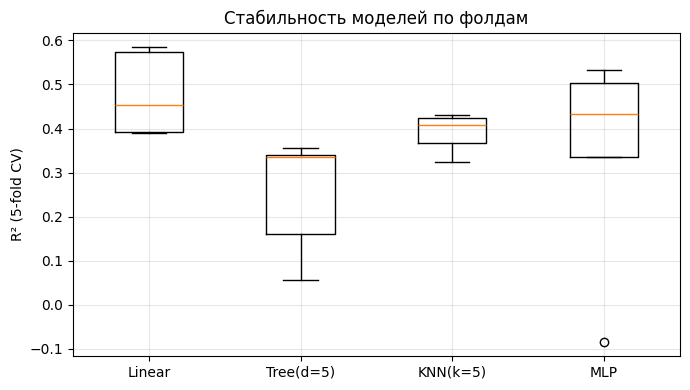

In [ ]:
# С4
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler as SS

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_cv = {
    "Linear": make_pipeline(SS(), LinearRegression()),
    "Tree(d=5)": make_pipeline(SS(), DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=5)),
    "KNN(k=5)": make_pipeline(SS(), KNeighborsRegressor(n_neighbors=5)),
    "MLP":      make_pipeline(SS(), MLPRegressor(hidden_layer_sizes=(64, 32),
                                                 max_iter=2000, random_state=RANDOM_STATE,
                                                 early_stopping=True)),
}

cv_scores = {name: cross_val_score(m, X, y, cv=cv, scoring="r2") for name, m in models_cv.items()}
for name, sc in cv_scores.items():
    print(f"{name:10s} R2 = {sc.mean():.3f} ± {sc.std():.3f}  {np.round(sc,3)}")

plt.figure(figsize=(7,4))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores))
plt.ylabel("R² (5-fold CV)")
plt.title("Стабильность моделей по фолдам")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---



## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Минимум 3 модели, минимум 2 метрики, минимум 1 визуализация.
